### 【[K線捕手](https://www.facebook.com/kevinyang20180801)盤前快訊】短線反彈，中期箱型  
昨天盤前提到加權指數遇到「季線、前低以及中長期上升趨勢線，三個複合式支撐」上漲152點，可惜成交量縮至3221億，法人小賣、融資續增、主力續賣，整體籌碼面也偏空方，因此短線還是反彈，中期箱型整理。  
趨勢正式翻空必須等到確認訊號：DMI的ADX值攀升到20以上、頭部頸線跌破，籌碼面則是外資現貨積極賣、外資期貨空單萬口以上、融資續增，但目前這些條件仍尚未齊全。  
而反過來觀察，加權指數趨勢要能止穩翻多，最基本3要件，類股結構必須改善，出現4個以上的主流類股，技術面也要回到多方軌道，可以先觀察17050能否站回，作為最基本的條件，成交量放大到10日均量之上。  
櫃買指數中長期的上升趨勢線已經跌破，中期翻空確認，慎防櫃買指數續弱牽動加權指數，以及個別國家指數的中期均線扣抵。最後提醒，一檔股票主力作手和控盤者一旦出完貨，是不可能會傻到回頭去幫散戶解套的，除非…他們還沒出完，或者是有另一批新的主力介入，但後兩者都是臆測，賣訊出現就該出，不要有懸念。而個股正式做頭後的反彈波，是操作難度最高的，做空容易短線被軋，做多萬一賣得不夠精確，還是有續跌風險，盡量多看少做。 (出處：K線捕手楊忠憲粉絲團)  
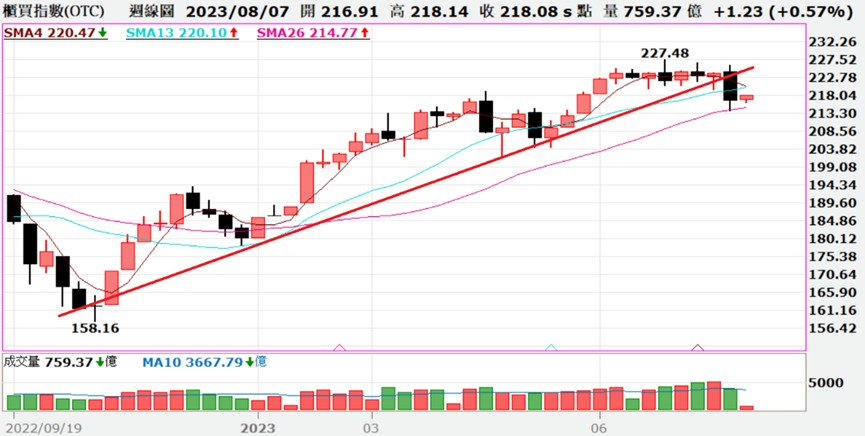  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [2]:
##### 使用2022年9月19日到今天收盤(2023年8月8日)的週K線資料繪製 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_OTC_230808.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA4','SMA13','MA6','MA12', 'DIF6-12','MACD2','OSC','K(6,3)','D(6,3)'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA6','MA12', 'DIF6-12','MACD2','OSC','K(6,3)','D(6,3)']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(pd.to_datetime(df_k_line['Date'],format='%Y-%m-%d'),inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(pd.to_datetime(df_sma['Date'],format='%Y-%m-%d'),inplace=True)
df_sma = df_sma.drop(columns=['Date'])

                Date   Price Type
DateIndex                        
4         2022-10-17  161.62   LO
11        2022-12-05  192.15   HI
14        2022-12-26  180.34   LO
29        2023-04-17  216.49   HI
33        2023-05-15  206.81   LO
41        2023-07-10  224.38   HI


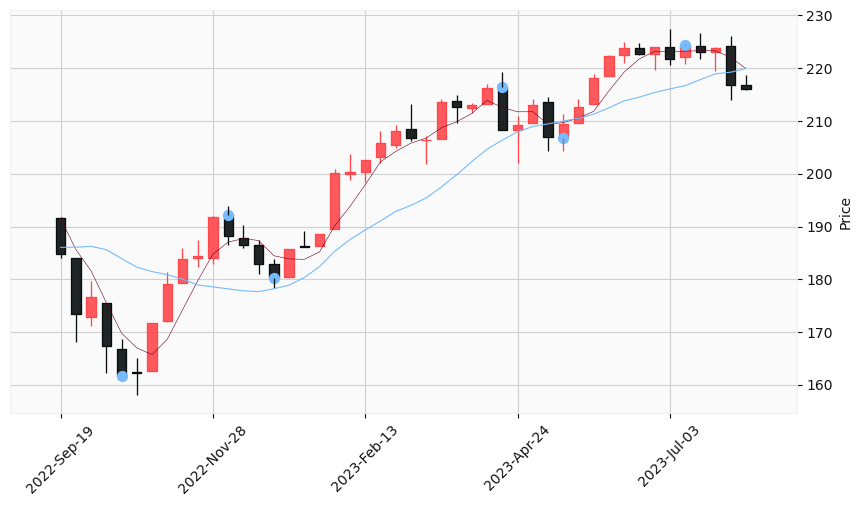

In [3]:
import myutils

# 尋找轉折點
_,_,max_min = myutils.FindingTurningPoints(df_k_line,'open_close',order=2)
print(max_min)

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定均線與轉折點    
turning_points_len = len(np.array(df_k_line['Close']))
turning_points = np.array([np.nan]*turning_points_len)
for point in max_min.iterrows() :
    turning_points[point[0]] = point[1]['Price']    
apds = [
    mpf.make_addplot(turning_points,type='scatter',marker='o',markersize=50,color='xkcd:sky blue'),
    mpf.make_addplot(df_sma['SMA4'],width=0.4,color='xkcd:maroon'),
    mpf.make_addplot(df_sma['SMA13'],width=0.8,color='xkcd:sky blue')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds)
mpf.plot(df_k_line,**kwargs)

In [4]:
def date_to_index(df_in,date_in) :
    number_array = df_in.index == date_in
    idx = 0
    for number_index in number_array :
        if number_index == True :
            break
        idx = idx + 1
    return idx

In [5]:
# 設定上升趨勢線
up_trendline_x = [4,33]
up_trendline_y = [max_min.loc[up_trendline_x[0]]['Price'],max_min.loc[up_trendline_x[1]]['Price']]
slope,intercept = np.polyfit(up_trendline_x,up_trendline_y,1)
up_trendline_start_date = '2022-10-17'
up_trendline_start_price = slope * date_to_index(df_k_line,'2022-10-17') + intercept
up_trendline_end_date = '2023-08-07'
up_trendline_end_price = slope * date_to_index(df_k_line,'2023-08-07') + intercept

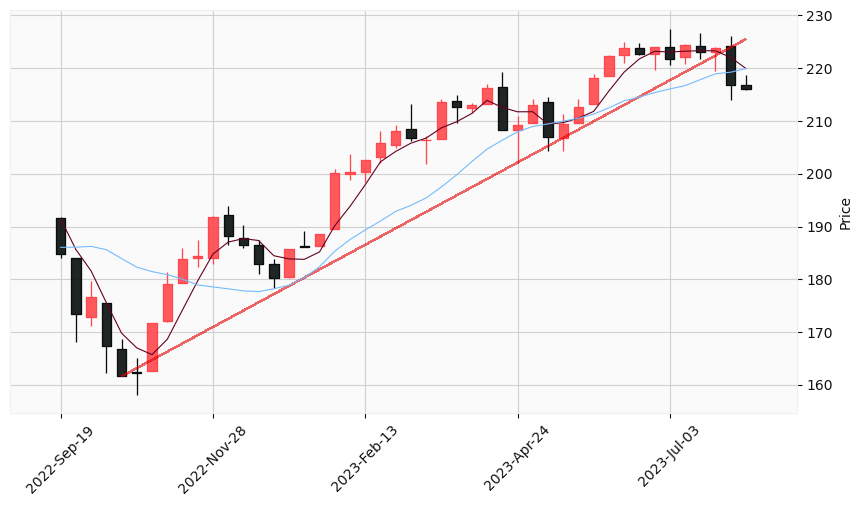

In [6]:
# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定上升趨勢線
seq_of_seq_of_points=[
    [(up_trendline_start_date,up_trendline_start_price),(up_trendline_end_date,up_trendline_end_price)]
                     ]

# 設定均線
apds = [
    mpf.make_addplot(df_sma['SMA4'],width=0.8,color='xkcd:maroon'),
    mpf.make_addplot(df_sma['SMA13'],width=0.8,color='xkcd:sky blue')
]

# 繪出K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), addplot=apds,alines=dict(alines=seq_of_seq_of_points, linewidths=1.0, colors='xkcd:red', alpha=0.6))
mpf.plot(df_k_line,**kwargs)

[AI股回神 空頭遭狠軋](https://readers.ctee.com.tw/cm/20230808/a01aa1/1252648/share)  
  
[日圓先生鐵口：年底升上130](https://readers.ctee.com.tw/cm/20230808/a03aa3/1252656/share)  
  
[找不到便宜撿…巴菲特現金滿到爆](https://readers.ctee.com.tw/cm/20230808/a03aa3/1252662/share)  
  
[道瓊勁揚逾400點 標普500收紅中止四連跌 波克夏創新高](https://money.udn.com/money/story/123398/7353748?from=edn_maintab_index)  
  
[台股ETF上演除息秀](https://money.udn.com/money/story/5618/7345358?from=ddd-umaylikenews_money_index)  

期貨開在平盤，仍在短線壓力之下：  
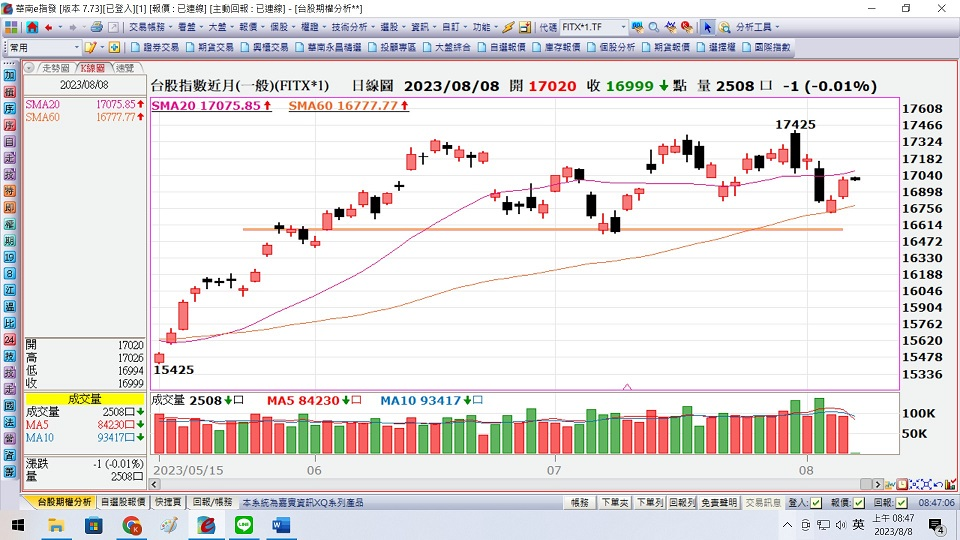  
  
跟期貨差不多，開平盤之上，但尚未突破短壓：  
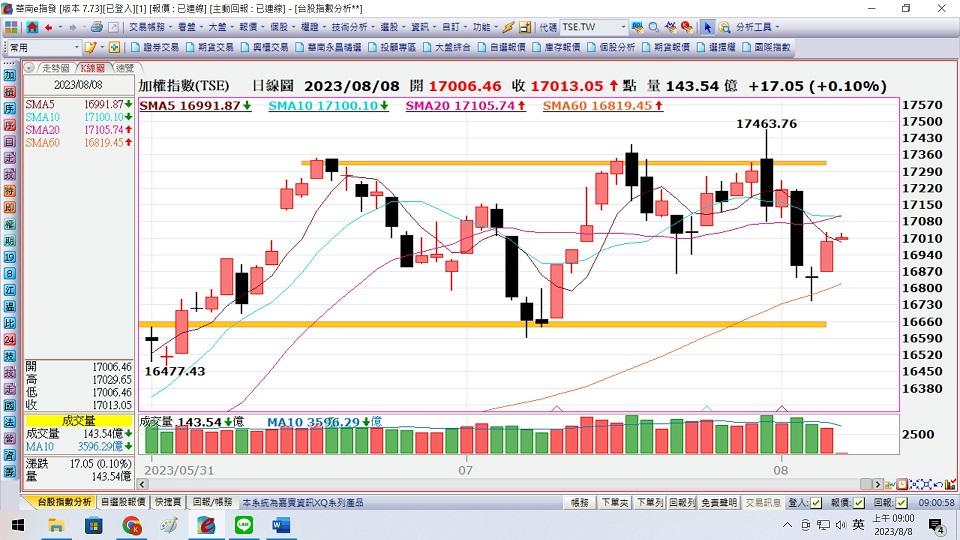  
  
頭部頸線：  
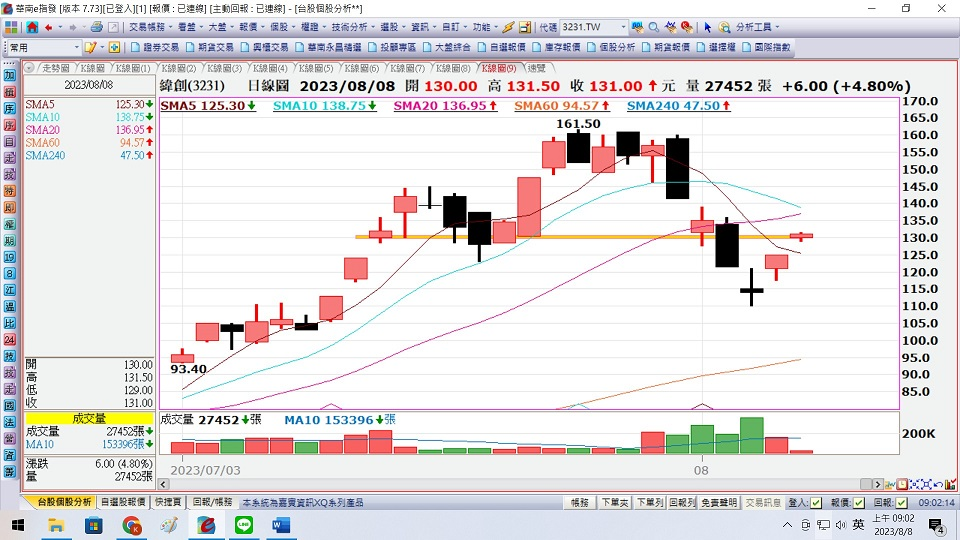  
  
櫃買指數明顯比較受到壓抑：  
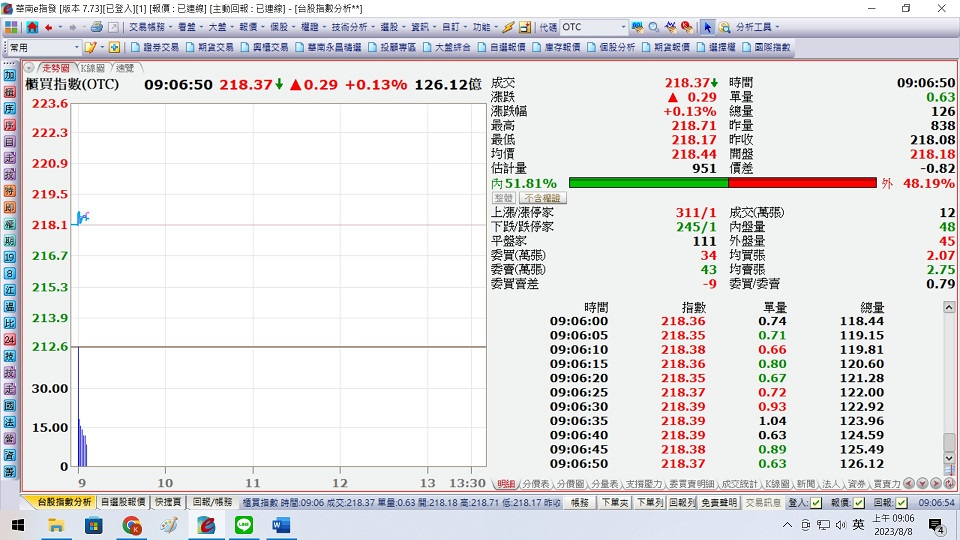  
  
台幣持續貶值：  
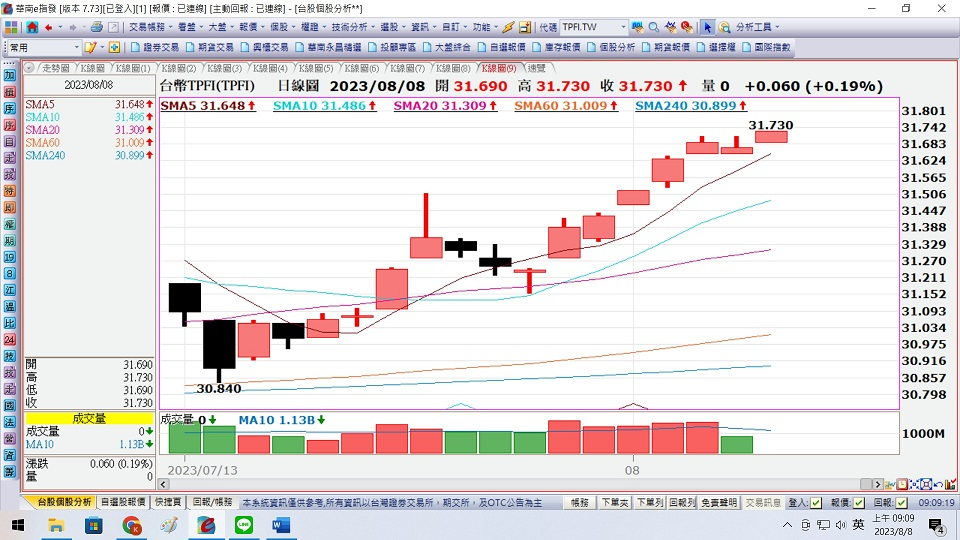  
  
到壓力就上不去：  
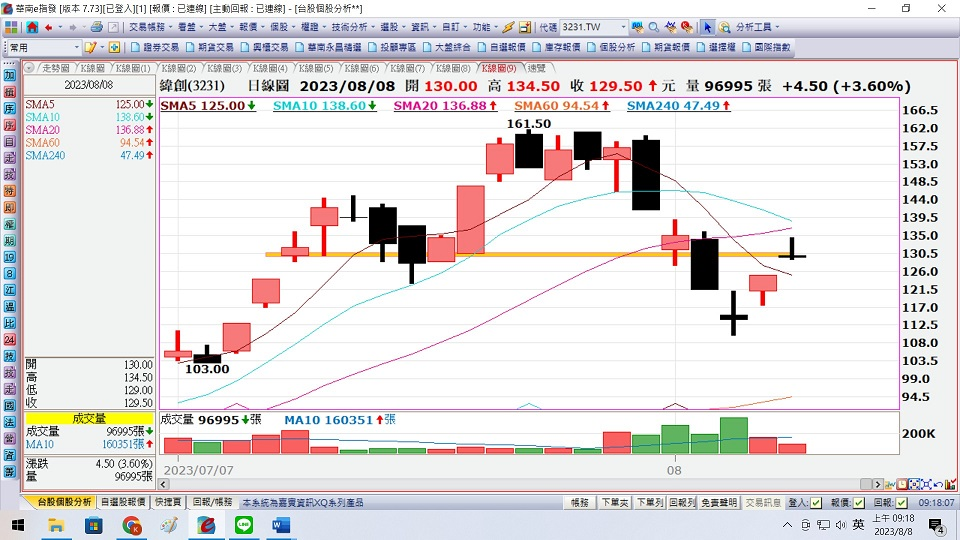  
  
有同學說，今天預估量有放大。這當然是沒錯，但我們希望的多方是上漲有量，目前反而是下跌才出量，那就不大健康了。  
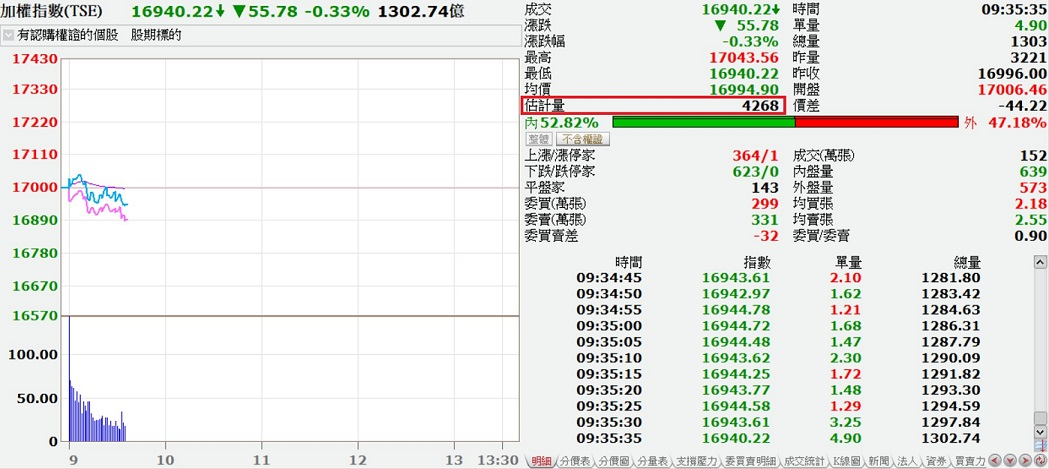  
  
然後還有股票的同學，是不是覺得跌幅又擴大了，因為櫃買指數賣壓又出來了，所以最近要多關心櫃買指數，不是加權指數喔
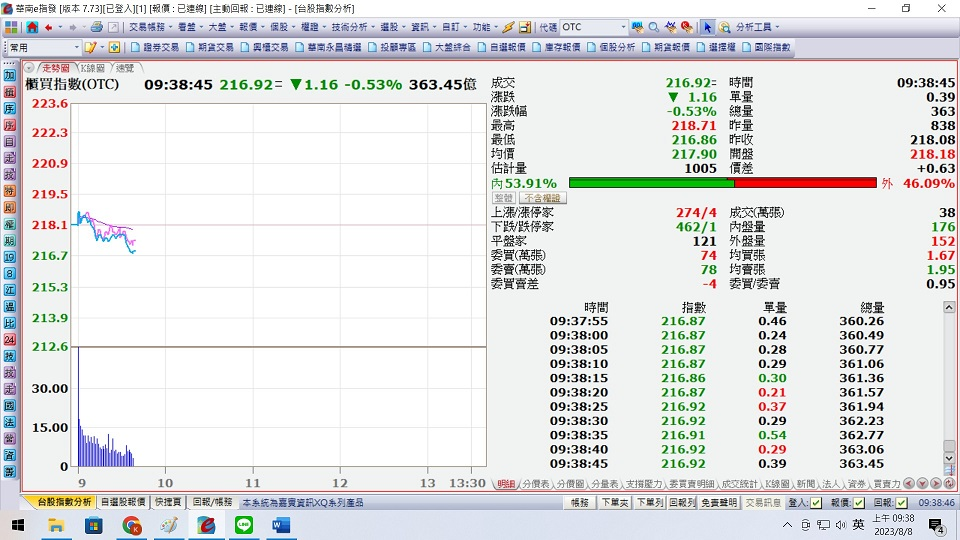

### 本日進度  
* **暫時空手**，觀察後續盤勢發展。  
* **[參賽](https://ithelp.ithome.com.tw/users/20161619/ironman/5955)** ： 2023 iThome 鐵人賽：用Python程式進行股票技術分析  
* [天瓏書局](https://www.tenlong.com.tw/)：  
  - [量化交易之路 : 用 Python 做股票量化分析](https://www.tenlong.com.tw/products/9787111575214?list_name=srh)  
    - [阿布量化交易系统](https://github.com/bbfamily/abu)  
    - [阿布量化AbuQuant](https://www.abuquant.com/)
  - [PyTorch 深度學習：電腦視覺流行專案親自動手](https://www.tenlong.com.tw/products/9786267146125?list_name=srh)  
  - [PyTorch深度學習之目標檢測](https://www.tenlong.com.tw/products/9787522602653?list_name=srh)  